In [3]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# Training data is 100 points in [0,1] inclusive regularly spaced
#train_x = torch.linspace(0, 1, 100)
# True function is sin(2*pi*x) with Gaussian noise
#train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

In [81]:
train_x = torch.asarray([ 0.9,  1.8,  3.6,  7.2, 14.4], dtype=torch.double)
#train_y = torch.asarray(np.log10([0.01301064, 0.00786519, 0.00639506, 0.00396935, 0.00264623]), dtype=torch.double)
train_y = torch.asarray(np.log10([[0.02506569, 0.02006725, 0.01859712, 0.01697998, 0.01573037,
        0.01301064, 0.00926181, 0.00970285, 0.01073194],
       [0.01896466, 0.01624492, 0.01154051, 0.0126431 , 0.01014389,
        0.00786519, 0.00837973, 0.00676259, 0.00705662],
       [0.01609791, 0.01205505, 0.00815921, 0.0069096 , 0.00793869,
        0.00639506, 0.00595402, 0.00492493, 0.0033813 ],
       [0.01154051, 0.00735064, 0.0069096 , 0.00521896, 0.00514545,
        0.00396935, 0.00323428, 0.00301376, 0.00213169],
       [0.00852675, 0.00661558, 0.00558649, 0.0034548 , 0.00330779,
        0.00264623, 0.00242571, 0.00132312, 0.00095558]]), dtype=torch.double).T

### Build the GP Model

In [100]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

#### Train it

In [101]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 100


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -torch.sum(mll(output, train_y))
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/100 - Loss: 24.188   lengthscale: 0.693   noise: 0.693
Iter 2/100 - Loss: 22.211   lengthscale: 0.744   noise: 0.744
Iter 3/100 - Loss: 20.569   lengthscale: 0.798   noise: 0.797
Iter 4/100 - Loss: 19.217   lengthscale: 0.853   noise: 0.850
Iter 5/100 - Loss: 18.109   lengthscale: 0.910   noise: 0.903
Iter 6/100 - Loss: 17.203   lengthscale: 0.969   noise: 0.953
Iter 7/100 - Loss: 16.461   lengthscale: 1.028   noise: 0.999
Iter 8/100 - Loss: 15.850   lengthscale: 1.089   noise: 1.041
Iter 9/100 - Loss: 15.343   lengthscale: 1.149   noise: 1.076
Iter 10/100 - Loss: 14.915   lengthscale: 1.210   noise: 1.106
Iter 11/100 - Loss: 14.549   lengthscale: 1.271   noise: 1.128
Iter 12/100 - Loss: 14.229   lengthscale: 1.332   noise: 1.142
Iter 13/100 - Loss: 13.944   lengthscale: 1.392   noise: 1.150
Iter 14/100 - Loss: 13.685   lengthscale: 1.452   noise: 1.150
Iter 15/100 - Loss: 13.444   lengthscale: 1.511   noise: 1.144
Iter 16/100 - Loss: 13.216   lengthscale: 1.569   noise: 1.132
I

In [110]:
model.eval()

ExactGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): RBFKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
)

In [111]:
model(test_x)

RuntimeError: shape '[459]' is invalid for input of size 4131

In [114]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 15, 51, dtype=torch.double)
    observed_pred = likelihood(model(test_x))

RuntimeError: shape '[51]' is invalid for input of size 459

ValueError: x and y must have same first dimension, but have shapes (5,) and (9, 5)

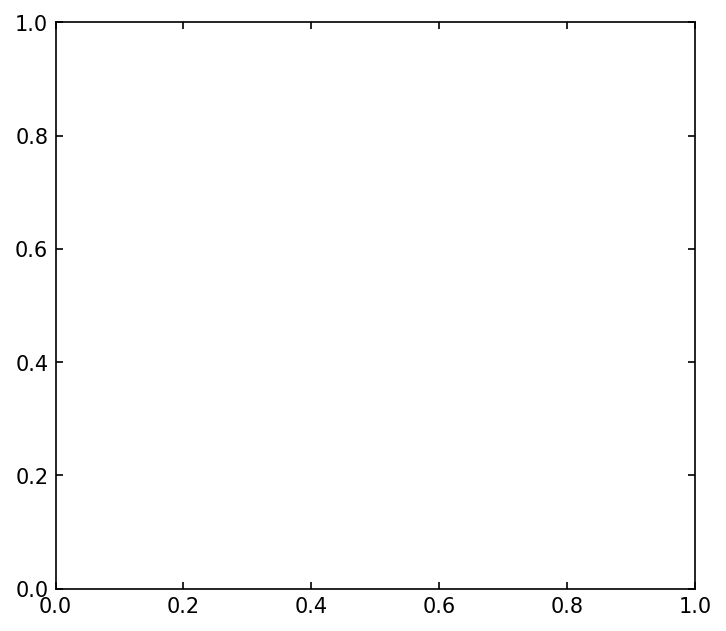

In [89]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=150)

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.legend(['Observed Data', 'Mean', 'Confidence'])